# Decision Tree

## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Read Dataset

In [3]:
# Load the dataset
data = pd.read_csv('preprocessed_loan_data.csv')

data.head()

,loan_percent_income,loan_int_rate,cb_person_cred_hist_length,person_age,credit_score,person_emp_exp,person_education_Associate,person_education_Bachelor,person_education_Doctorate,person_education_High School,...,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,person_gender,previous_loan_defaults_on_file,loan_status
0,1.000000,0.715620,0.087589,0.14898,0.250733,0.000000,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0,0
1,0.175824,0.401104,0.014596,0.10092,0.058291,0.000000,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,1,1
2,0.967033,0.512603,0.087589,0.29316,0.500570,0.162162,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0,0
3,0.967033,0.664705,0.014596,0.19704,0.635617,0.000000,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0,0
4,1.000000,0.602833,0.160582,0.24510,0.335137,0.054054,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1,0,0


In [4]:
#shape
data.shape

(70000, 24)

# Split the data

In [5]:
# Separate feature columns and target column
X = data.drop('loan_status', axis=1)   # All columns except the target
Y = data['loan_status']                # Target column

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.20)

In [7]:
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (56000, 23)
Testing set shape: (14000, 23)


In [8]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [9]:
dt.score(X_test, y_test)

0.8866428571428572

## Hyperparameter Tuning - GridSearchCV (Decision Tree)

In [10]:
from sklearn.model_selection import GridSearchCV

# Grid 1
param_grid_dt_1 = {
    'max_depth': [3],                
    'min_samples_split': [10],    
    'criterion': ['gini']
}

# Grid 2
param_grid_dt_2 = {
    'max_depth': [5, 10],            
    'min_samples_split': [2, 5],     
    'criterion': ['gini', 'entropy']
}

# Grid 3
param_grid_dt_3 = {
    'max_depth': [None, 15, 20],     
    'min_samples_split': [2, 3],    
    'criterion': ['entropy', 'gini']
}

In [11]:
# Grid 1
grid_dt_1 = GridSearchCV(estimator=dt, param_grid=param_grid_dt_1, cv=10)
grid_dt_1.fit(X_train, y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini'], 'max_depth': [3], 'min_samples_split': [10]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [12]:
grid_dt_1.best_params_

{'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 10}

In [13]:
grid_dt_1.score(X_test, y_test)

0.8264285714285714

In [14]:
# Grid 2
grid_dt_2 = GridSearchCV(estimator=dt, param_grid=param_grid_dt_2, cv=10)
grid_dt_2.fit(X_train, y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [5, 10], 'min_samples_split': [2, 5]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [15]:
grid_dt_2.best_params_

{'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 2}

In [16]:
grid_dt_2.score(X_test, y_test)

0.8902142857142857

In [17]:
# Grid 3
grid_dt_3 = GridSearchCV(estimator=dt, param_grid=param_grid_dt_3, cv=10)
grid_dt_3.fit(X_train, y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['entropy', 'gini'], 'max_depth': [None, 15, ...], 'min_samples_split': [2, 3]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [18]:
grid_dt_3.best_params_

{'criterion': 'entropy', 'max_depth': 15, 'min_samples_split': 2}

In [19]:
grid_dt_3.score(X_test, y_test)

0.8982142857142857

In [20]:
# Evaluation Metrics

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# List of trained GridSearchCV models
grids = [grid_dt_1, grid_dt_2, grid_dt_3]
grid_names = ["Desicion Tree Grid 1", "Desicion Tree Grid 2", "Desicion Tree Grid 3"]

# Prepare empty list to store results
results = []

for name, grid in zip(grid_names, grids):
    y_pred = grid.predict(X_test)   # Predict on test set
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append([name, acc, prec, rec, f1])

# Create DataFrame
df_dt = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"])

# Display
df_dt

,Model,Accuracy,Precision,Recall,F1-score
0,Desicion Tree Grid 1,0.826429,0.765310,0.936336,0.842228
1,Desicion Tree Grid 2,0.890214,0.865275,0.921611,0.892555
2,Desicion Tree Grid 3,0.898214,0.875512,0.925942,0.900021


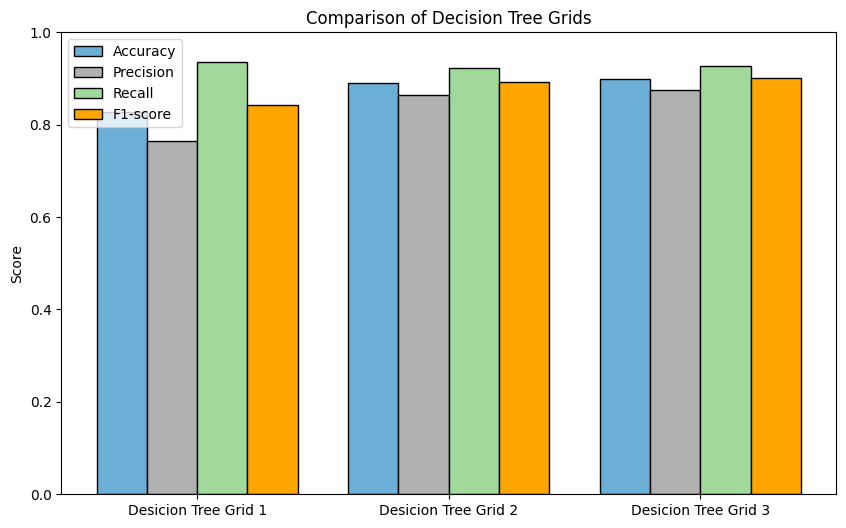

In [22]:
plt.figure(figsize=(10,6))

metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
x = range(len(df_dt))
width = 0.2

# Define different colors for each metric
colors = ['#6BAED6', '#B0B0B0', '#A1D99B', 'orange']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    plt.bar([p + width*i for p in x], df_dt[metric], width=width, label=metric, color=color, edgecolor='black')

plt.xticks([p + 1.5*width for p in x], df_dt["Model"])
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Comparison of Decision Tree Grids")
plt.legend()
plt.show()